num feasible setups: 147
best score (brute-force): 0.5562
min latency (brute-force): 83.1065
Most equal thread % split: tp=[4, 4, 4], threads=[50, 50, 80] -> score=0.5309, latency=100.2480
Most size-proportional thread % split: tp=[4, 4, 4], threads=[40, 90, 50] subset=(0, 1, 2) -> score=0.5387, latency=97.2994
Max score among no-GPU-sharing packings: tp=[4, 2, 2], threads=[90, 100, 90] subset=(0, 1, 2) -> score=0.5562, latency=98.6624
Saved: plots/score_latency_scatter_brute_force_8g_lam50_tau100.pdf


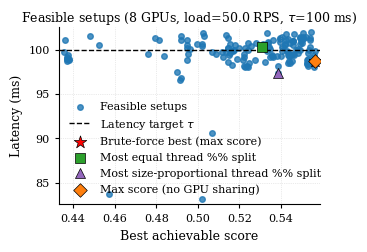

In [4]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from resource_allocation.brute_force_setup import SetupCandidate, load_result
from resource_allocation.models_config import ROUTING_MODELS
from resource_allocation.resource_packing import check_feasibility


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "resource_allocation").is_dir():
        return cwd
    if (cwd.parent / "resource_allocation").is_dir():
        return cwd.parent
    return cwd


os.chdir(_repo_root())

# Pickle path must look like: brute_force_{G}g_lam{λ}_tau{τ}.pkl
RESULT_PATH = "resource_allocation/brute_force_results/brute_force_8g_lam50_tau100.pkl"


def parse_brute_force_path(path: str | Path) -> tuple[int, float, int]:
    """Parse G, λ, τ from `brute_force_{G}g_lam{λ}_tau{τ}.pkl`."""
    name = Path(path).name
    m = re.match(r"brute_force_(\d+)g_lam([\d.]+)_tau(\d+)\.pkl$", name)
    if not m:
        raise ValueError(
            "Expected filename brute_force_<G>g_lam<λ>_tau<τ>.pkl, got: " + repr(name)
        )
    g, lam_s, tau_s = m.groups()
    return int(g), float(lam_s), int(tau_s)


def _thread_int_to_frac(thread_percentage: int) -> float:
    return float(thread_percentage) / 100.0


def find_most_equal_thread_split(
    candidates: list[SetupCandidate],
) -> tuple[SetupCandidate, float, float]:
    """
    Among feasible setups with all backends deployed (|subset| = len(ROUTING_MODELS)),
    pick the one whose per-model *total* CPU thread demand is closest to even.
    Total demand for model k is tp_k * thread_frac_k (matches packing / brute force),
    not raw `thread_levels[k]` alone.

    Tie-break: lower (max - min) of total demand, then lower variance of TP levels.
    Returns (candidate, best_score, best_latency).
    """
    if not candidates:
        raise ValueError("candidates is empty")

    best: SetupCandidate | None = None
    best_key: tuple | None = None

    for c in candidates:
        if len(c.subset) != len(ROUTING_MODELS):
            continue
        th_frac = np.asarray(
            [_thread_int_to_frac(int(t)) for t in c.thread_levels], dtype=float
        )
        tp = np.asarray(c.tp_levels, dtype=float)
        if th_frac.size == 0:
            continue
        total_demand = tp * th_frac
        var_tot = float(np.var(total_demand))
        spread_tot = float(np.max(total_demand) - np.min(total_demand))
        var_tp = float(np.var(tp)) if tp.size else 0.0
        key = (var_tot, spread_tot, var_tp)
        if best is None or key < best_key:  # type: ignore[operator]
            best = c
            best_key = key

    if best is None:
        raise ValueError("no full-deployment candidate with thread_levels")

    assert best.best_score is not None and best.best_latency is not None
    return best, float(best.best_score), float(best.best_latency)


# Billions of parameters; keys match ROUTING_MODELS[].model_id
_MODEL_PARAM_BILLIONS_BY_ID: dict[str, float] = {
    "mistral-7b": 7.0,
    "yi-34b": 34.0,
    "vicuna-13b": 13.0,
}


def find_most_size_proportional_thread_split(
    candidates: list[SetupCandidate],
) -> tuple[SetupCandidate, float, float]:
    """
    Among feasible setups with all backends deployed (|subset| = len(ROUTING_MODELS)),
    pick the one whose normalized *total* per-model thread demand (tp * thread_frac)
    is closest to splitting CPU proportionally to each model's size (param billions).

    Minimizes MSE between normalized demand shares and ideal weights
    size_i / sum_j size_j. Tie-break: lower L1 deviation.
    Returns (candidate, best_score, best_latency).
    """
    if not candidates:
        raise ValueError("candidates is empty")

    best: SetupCandidate | None = None
    best_key: tuple | None = None

    for c in candidates:
        if len(c.subset) != len(ROUTING_MODELS):
            continue
        th_frac = np.asarray(
            [_thread_int_to_frac(int(t)) for t in c.thread_levels], dtype=float
        )
        tp = np.asarray(c.tp_levels, dtype=float)
        if th_frac.size == 0:
            continue
        try:
            sizes = np.array(
                [_MODEL_PARAM_BILLIONS_BY_ID[ROUTING_MODELS[i].model_id] for i in c.subset],
                dtype=float,
            )
        except KeyError:
            continue
        if sizes.size != th_frac.size:
            continue
        demand = tp * th_frac
        ssum = float(sizes.sum())
        dsum = float(demand.sum())
        if ssum <= 0.0 or dsum <= 0.0:
            continue
        ideal = sizes / ssum
        obs = demand / dsum
        mse = float(np.sum((obs - ideal) ** 2))
        l1 = float(np.sum(np.abs(obs - ideal)))
        key = (mse, l1)
        if best is None or key < best_key:  # type: ignore[operator]
            best = c
            best_key = key

    if best is None:
        raise ValueError(
            "no full-deployment candidate with valid thread_levels / subset"
        )

    assert best.best_score is not None and best.best_latency is not None
    return best, float(best.best_score), float(best.best_latency)


def packing_has_at_most_one_shard_per_gpu(
    candidate: SetupCandidate, num_gpus: int
) -> bool:
    """
    True iff FFD assigns at most one shard to each GPU (no two models share a GPU).
    Uses `check_feasibility` / `build_shards` like brute force: for each model k,
    there are tp_k shards, each with thread demand thread_frac[k], so total thread
    demand for that model is tp_k * thread_frac[k] (likewise memory is per shard).
    """
    thread_fracs = [_thread_int_to_frac(th) for th in candidate.thread_levels]
    feas = check_feasibility(
        tp_levels=np.asarray(candidate.tp_levels, dtype=int),
        thread_percentages=thread_fracs,
        memory_percentages=np.asarray(candidate.memory_levels, dtype=float),
        num_gpus=num_gpus,
    )
    if not feas.feasible:
        return False
    return all(len(shard_ids) <= 1 for shard_ids in feas.assignment)


def find_max_score_no_shared_gpu(
    candidates: list[SetupCandidate],
    num_gpus: int,
) -> tuple[SetupCandidate, float, float]:
    """
    Among feasible setups with all backends deployed (|subset| = len(ROUTING_MODELS))
    whose packing puts at most one shard per GPU, return the one with maximum best_score.
    """
    filtered = [
        c
        for c in candidates
        if len(c.subset) == len(ROUTING_MODELS)
        and packing_has_at_most_one_shard_per_gpu(c, num_gpus)
    ]
    if not filtered:
        raise ValueError(
            "no full-deployment feasible setup with at most one shard per GPU "
            "(no shared-GPU packing)"
        )
    best = max(
        filtered,
        key=lambda c: float(c.best_score) if c.best_score is not None else -1e300,
    )
    assert best.best_score is not None and best.best_latency is not None
    return best, float(best.best_score), float(best.best_latency)


gpu_count, input_load, latency_threshold = parse_brute_force_path(RESULT_PATH)

# ---------------------------
# Load brute-force scatter
# ---------------------------
data = load_result(path=RESULT_PATH)
feasible_data = data.all_feasible

scores = np.array([row.best_score for row in feasible_data], dtype=float)
latencies = np.array([row.best_latency for row in feasible_data], dtype=float)

print(f"num feasible setups: {len(feasible_data)}")
print(f"best score (brute-force): {scores.max():.4f}")
print(f"min latency (brute-force): {latencies.min():.4f}")

# Brute-force reference: max score among feasible packings
best_idx = np.argmax(scores)
bf_score = float(scores[best_idx])
bf_latency = float(latencies[best_idx])

eq_cand, eq_score, eq_latency = find_most_equal_thread_split(feasible_data)
print(
    "Most equal thread % split:",
    f"tp={eq_cand.tp_levels}, threads={eq_cand.thread_levels}",
    f"-> score={eq_score:.4f}, latency={eq_latency:.4f}",
)

prop_cand, prop_score, prop_latency = find_most_size_proportional_thread_split(
    feasible_data
)
print(
    "Most size-proportional thread % split:",
    f"tp={prop_cand.tp_levels}, threads={prop_cand.thread_levels}",
    f"subset={prop_cand.subset}",
    f"-> score={prop_score:.4f}, latency={prop_latency:.4f}",
)

noshare_cand, noshare_score, noshare_latency = find_max_score_no_shared_gpu(
    feasible_data,
    gpu_count,
)
print(
    "Max score among no-GPU-sharing packings:",
    f"tp={noshare_cand.tp_levels}, threads={noshare_cand.thread_levels}",
    f"subset={noshare_cand.subset}",
    f"-> score={noshare_score:.4f}, latency={noshare_latency:.4f}",
)

# ---------------------------
# Paper-ready style
# ---------------------------
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

fig, ax = plt.subplots(figsize=(3.35, 2.4))

ax.scatter(
    scores,
    latencies,
    s=16,
    alpha=0.8,
    label="Feasible setups",
)

ax.axhline(
    latency_threshold,
    linestyle="--",
    linewidth=1.0,
    color="black",
    label=r"Latency target $\tau$",
)

ax.scatter(
    [bf_score],
    [bf_latency],
    marker="*",
    s=90,
    color="red",
    edgecolors="black",
    linewidths=0.5,
    zorder=4,
    label="Brute-force best (max score)",
)

ax.scatter(
    [eq_score],
    [eq_latency],
    marker="s",
    s=52,
    color="tab:green",
    edgecolors="black",
    linewidths=0.5,
    zorder=5,
    label="Most equal thread %% split",
)

ax.scatter(
    [prop_score],
    [prop_latency],
    marker="^",
    s=52,
    color="tab:purple",
    edgecolors="black",
    linewidths=0.5,
    zorder=5,
    label="Most size-proportional thread %% split",
)

ax.scatter(
    [noshare_score],
    [noshare_latency],
    marker="D",
    s=48,
    color="tab:orange",
    edgecolors="black",
    linewidths=0.5,
    zorder=5,
    label="Max score (no GPU sharing)",
)

ax.set_xlabel("Best achievable score")
ax.set_ylabel("Latency (ms)")
ax.set_title(
    f"Feasible setups ({gpu_count} GPUs, load={input_load} RPS, $\\tau$={latency_threshold} ms)",
    pad=4,
)

ax.grid(True, linestyle=":", linewidth=0.5, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

all_s = np.concatenate(
    [scores, [bf_score, eq_score, prop_score, noshare_score]]
)
all_l = np.concatenate(
    [latencies, [bf_latency, eq_latency, prop_latency, noshare_latency]]
)
x_margin = 0.02 * (all_s.max() - all_s.min() + 1e-8)
y_margin = 0.03 * (all_l.max() - all_l.min() + 1e-8)
ax.set_xlim(all_s.min() - x_margin, all_s.max() + x_margin)
ax.set_ylim(all_l.min() - y_margin, all_l.max() + y_margin)

ax.legend(frameon=False, loc="best")

plt.tight_layout(pad=0.3)

out_dir = Path("plots")
out_dir.mkdir(parents=True, exist_ok=True)
stem = Path(RESULT_PATH).stem
out_path = out_dir / f"score_latency_scatter_{stem}.pdf"
plt.savefig(out_path, bbox_inches="tight")
print(f"Saved: {out_path}")

plt.show()